<a href="https://colab.research.google.com/github/IrineuBovoJunior398/Pos-em-IA/blob/main/C%C3%B3pia_de_SALVO_PDF_BANCARIO_DATASET_EXECUTADO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. CARREGANDO E PRÉ-PROCESSANDO DADOS BANCÁRIOS
✓ Arquivo carregado com sucesso de: /content/BANCARIO.csv
Dataset carregado com 21 amostras e 4 colunas
Colunas encontradas: ['Conta', 'Renda', 'Dívida', 'Classe']

VERIFICAÇÃO DAS COLUNAS
✓ Coluna de renda identificada: 'Renda'
✓ Coluna de dívida identificada: 'Dívida'
✓ Coluna de classe identificada: 'Classe'
✓ Conversão para float realizada com sucesso

Classes encontradas: ['bom' 'mau']
Codificação: {'bom': np.int64(0), 'mau': np.int64(1)}
Distribuição de classes: [12  9] (Classe 0: 12, Classe 1: 9)

2. NORMALIZAÇÃO DOS DADOS
ESTATÍSTICAS ANTES DA NORMALIZAÇÃO:
Média: [1728.57, 409.05]
Desvio padrão: [702.81, 234.92]
Mínimo: [450.00, 70.00]
Máximo: [2800.00, 800.00]

ESTATÍSTICAS APÓS NORMALIZAÇÃO:
Média: [-0.000, -0.000]
Desvio padrão: [1.000, 1.000]

3. MAPEAMENTO PARA ESPAÇO NÃO-LINEAR
Adicionada feature polinomial (renda² + dívida²)
Dimensões: (21, 3) (era (21, 2))

4. DIVISÃO TREINO/TESTE
Treino: 14 amostras
Teste: 7 amostras
Dis

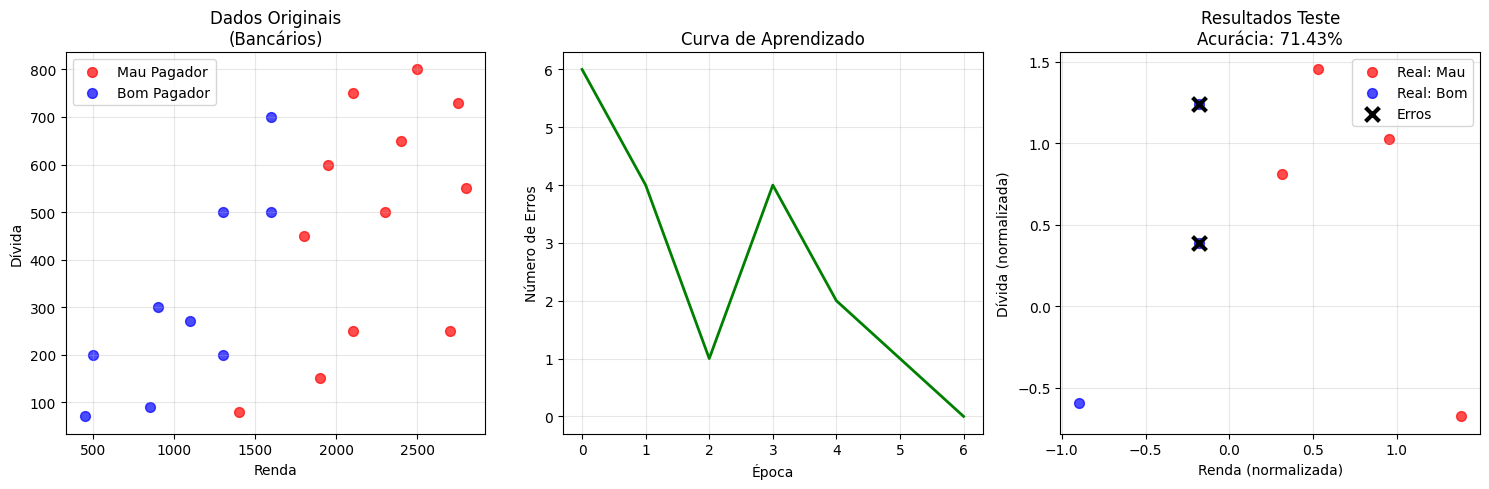


8. RESUMO DOS PARÂMETROS
Taxa de Aprendizagem: 0.01
Máximo de Épocas: 1000
Proporção Teste: 0.3
Features Polinomiais: Sim
Acurácia Final no Teste: 71.43%

DICAS PARA EXPERIMENTOS:
• Aumente TAXA_APRENDIZAGEM para convergência mais rápida (risco de oscilação)
• Diminua TAXA_APRENDIZAGEM para convergência mais estável (mais lento)
• Mude TEST_SIZE para testar com mais/menos dados de treino
• Desligue ADICIONAR_FEATURE_POLINOMIAL para testar linearidade
• Compare resultados com diferentes RANDOM_STATE


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import sys

# ============================================================================
# CONFIGURAÇÕES EDITÁVEIS (ALTERE AQUI PARA NOVOS TESTES)
# ============================================================================
TAXA_APRENDIZAGEM = 0.01  # Taxa de aprendizagem do Perceptron (experimente: 0.001, 0.1, 1.0)
MAX_EPOCAS = 1000         # Máximo de épocas de treinamento (experimente: 100, 5000)
TEST_SIZE = 0.3           # Proporção de dados para teste (0.2 = 20%, 0.4 = 40%)
RANDOM_STATE = 42         # Semente para reprodutibilidade
ADICIONAR_FEATURE_POLINOMIAL = True  # Adicionar renda² + dívida² para não-linearidade

# ============================================================================
# 1. CARREGAMENTO E PRÉ-PROCESSAMENTO DOS DADOS
# ============================================================================
print("=" * 70)
print("1. CARREGANDO E PRÉ-PROCESSANDO DADOS BANCÁRIOS")
print("=" * 70)

# Tratamento robusto de erro para carregamento do arquivo
caminhos_possiveis = ['/content/BANCARIO.csv']
df = None
for caminho in caminhos_possiveis:
    try:
        df = pd.read_csv(caminho)
        print(f"✓ Arquivo carregado com sucesso de: {caminho}")
        break
    except FileNotFoundError:
        continue
    except Exception as e:
        print(f"ERRO inesperado ao carregar {caminho}: {e}")
        continue

if df is None:
    print("ERRO: Arquivo BANCARIO.csv não encontrado em nenhum caminho!")
    print("Caminhos tentados:", caminhos_possiveis)
    print("Faça upload do arquivo ou verifique o nome.")
    sys.exit(1)

# Verificar se o DataFrame não está vazio
if df.empty:
    print("ERRO: O arquivo CSV está vazio!")
    sys.exit(1)

print(f"Dataset carregado com {len(df)} amostras e {len(df.columns)} colunas")
print("Colunas encontradas:", list(df.columns))

# ============================================================================
# CORREÇÃO PARA COLUNAS: Verificar e ajustar nomes das colunas
# ============================================================================
print("\n" + "=" * 70)
print("VERIFICAÇÃO DAS COLUNAS")
print("=" * 70)

# Possíveis nomes de colunas (considerando variações)
colunas_possiveis_renda = ['renda', 'Renda', 'RENDA', 'income', 'Income', 'INCOME']
colunas_possiveis_divida = ['divida', 'Divida', 'DÍVIDA', 'divida', 'Divida', 'DÍVIDA', 'debt', 'Debt', 'DEBT']
colunas_possiveis_classe = ['classe', 'Classe', 'CLASSE', 'class', 'Class', 'CLASS', 'target', 'Target', 'TARGET']

# Encontrar as colunas corretas
coluna_renda = None
coluna_divida = None
coluna_classe = None

for col in df.columns:
    col_lower = col.strip().lower()
    if col_lower in [c.lower() for c in colunas_possiveis_renda]:
        coluna_renda = col
    elif col_lower in [c.lower() for c in colunas_possiveis_divida]:
        coluna_divida = col
    elif col_lower in [c.lower() for c in colunas_possiveis_classe]:
        coluna_classe = col

if coluna_renda is None or coluna_divida is None or coluna_classe is None:
    print("ERRO: Não foi possível encontrar as colunas necessárias!")
    print(f"Colunas encontradas: {list(df.columns)}")
    print("Esperado: uma coluna de renda, uma de dívida e uma de classe")
    print("\nVerifique se o arquivo CSV tem as colunas corretas.")
    print("Exemplo de formato esperado:")
    print("conta,renda,divida,classe")
    print("1,1500,200,bom")
    sys.exit(1)

print(f"✓ Coluna de renda identificada: '{coluna_renda}'")
print(f"✓ Coluna de dívida identificada: '{coluna_divida}'")
print(f"✓ Coluna de classe identificada: '{coluna_classe}'")

# Separar features (X) e target (y)
try:
    X = df[[coluna_renda, coluna_divida]].astype(float).values  # Converte para numpy array de floats
    print("✓ Conversão para float realizada com sucesso")
except ValueError as e:
    print(f"ERRO na conversão para float: {e}")
    print("Verifique se as colunas contêm apenas números válidos")
    print(f"Conteúdo da coluna {coluna_renda}: {df[coluna_renda].head()}")
    print(f"Conteúdo da coluna {coluna_divida}: {df[coluna_divida].head()}")
    sys.exit(1)

y_raw = df[coluna_classe].values  # Classes

# Codificar classes para números (bom=1, mau=0 ou similar)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

print(f"\nClasses encontradas: {label_encoder.classes_}")
print(f"Codificação: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")
print(f"Distribuição de classes: {np.bincount(y)} (Classe 0: {np.sum(y==0)}, Classe 1: {np.sum(y==1)})")

# ============================================================================
# 2. NORMALIZAÇÃO DOS DADOS
# ============================================================================
print("\n" + "=" * 70)
print("2. NORMALIZAÇÃO DOS DADOS")
print("=" * 70)

print("ESTATÍSTICAS ANTES DA NORMALIZAÇÃO:")
print(f"Média: [{np.mean(X[:, 0]):.2f}, {np.mean(X[:, 1]):.2f}]")
print(f"Desvio padrão: [{np.std(X[:, 0]):.2f}, {np.std(X[:, 1]):.2f}]")
print(f"Mínimo: [{np.min(X[:, 0]):.2f}, {np.min(X[:, 1]):.2f}]")
print(f"Máximo: [{np.max(X[:, 0]):.2f}, {np.max(X[:, 1]):.2f}]")

scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

print("\nESTATÍSTICAS APÓS NORMALIZAÇÃO:")
print(f"Média: [{np.mean(X_normalized[:, 0]):.3f}, {np.mean(X_normalized[:, 1]):.3f}]")
print(f"Desvio padrão: [{np.std(X_normalized[:, 0]):.3f}, {np.std(X_normalized[:, 1]):.3f}]")

# ============================================================================
# 3. MAPEAMENTO PARA ESPAÇO NÃO-LINEAR (OPCIONAL)
# ============================================================================
print("\n" + "=" * 70)
print("3. MAPEAMENTO PARA ESPAÇO NÃO-LINEAR")
print("=" * 70)

if ADICIONAR_FEATURE_POLINOMIAL:
    # Adiciona feature polinomial: renda² + dívida²
    X_mapeado = np.column_stack([
        X_normalized[:, 0],  # renda normalizada
        X_normalized[:, 1],  # dívida normalizada
        X_normalized[:, 0]**2 + X_normalized[:, 1]**2  # renda² + dívida²
    ])
    print("Adicionada feature polinomial (renda² + dívida²)")
    print(f"Dimensões: {X_mapeado.shape} (era {X_normalized.shape})")
else:
    X_mapeado = X_normalized
    print("Mantidas apenas features originais")

# ============================================================================
# 4. DIVISÃO TREINO/TESTE
# ============================================================================
print("\n" + "=" * 70)
print("4. DIVISÃO TREINO/TESTE")
print("=" * 70)

X_train, X_test, y_train, y_test = train_test_split(
    X_mapeado, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Treino: {len(X_train)} amostras")
print(f"Teste: {len(X_test)} amostras")
print(f"Distribuição treino: Classe 0: {np.sum(y_train==0)}, Classe 1: {np.sum(y_train==1)}")
print(f"Distribuição teste: Classe 0: {np.sum(y_test==0)}, Classe 1: {np.sum(y_test==1)}")

# ============================================================================
# 5. IMPLEMENTAÇÃO DO PERCEPTRON
# ============================================================================
print("\n" + "=" * 70)
print("5. TREINANDO PERCEPTRON")
print("=" * 70)

class Perceptron:
    def __init__(self, taxa_aprendizagem=0.01, max_epocas=1000):
        self.taxa_aprendizagem = taxa_aprendizagem
        self.max_epocas = max_epocas
        self.pesos = None
        self.bias = None
        self.erros_por_epoca = []

    def treinar(self, X, y):
        n_amostras, n_features = X.shape
        self.pesos = np.zeros(n_features)
        self.bias = 0
        self.erros_por_epoca = []

        for epoca in range(self.max_epocas):
            erros = 0
            for i in range(n_amostras):
                saida_linear = np.dot(X[i], self.pesos) + self.bias
                y_pred = 1 if saida_linear >= 0 else 0

                if y_pred != y[i]:
                    erro = y[i] - y_pred
                    self.pesos += self.taxa_aprendizagem * erro * X[i]
                    self.bias += self.taxa_aprendizagem * erro
                    erros += 1

            self.erros_por_epoca.append(erros)

            if erros == 0:
                print(f"✓ Convergiu na época {epoca + 1}")
                break

            if (epoca + 1) % 100 == 0:
                print(f"Época {epoca + 1}: {erros} erros")

        return self

    def prever(self, X):
        saida_linear = np.dot(X, self.pesos) + self.bias
        return np.where(saida_linear >= 0, 1, 0)

    def acuracia(self, X, y):
        y_pred = self.prever(X)
        return np.mean(y_pred == y)

# Treinar o Perceptron
perceptron = Perceptron(taxa_aprendizagem=TAXA_APRENDIZAGEM, max_epocas=MAX_EPOCAS)
perceptron.treinar(X_train, y_train)

# Avaliar
acuracia_treino = perceptron.acuracia(X_train, y_train)
acuracia_teste = perceptron.acuracia(X_test, y_test)

print(f"\nAcurácia no TREINO: {acuracia_treino:.2%}")
print(f"Acurácia no TESTE: {acuracia_teste:.2%}")

# ============================================================================
# 6. MÉTRICAS DETALHADAS E VISUALIZAÇÃO
# ============================================================================
print("\n" + "=" * 70)
print("6. MÉTRICAS DETALHADAS")
print("=" * 70)

y_pred_teste = perceptron.prever(X_test)
print("RELATÓRIO DE CLASSIFICAÇÃO:")
print(classification_report(y_test, y_pred_teste, target_names=['Mau Pagador', 'Bom Pagador']))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_teste)
print("\nMATRIZ DE CONFUSÃO:")
print("                 Previsto")
print("                 Mau    Bom")
print(f"Real  Mau     {cm[0][0]:3d}    {cm[0][1]:3d}")
print(f"      Bom     {cm[1][0]:3d}    {cm[1][1]:3d}")

# ============================================================================
# 7. VISUALIZAÇÃO DOS RESULTADOS
# ============================================================================
print("\n" + "=" * 70)
print("7. VISUALIZAÇÃO DOS RESULTADOS")
print("=" * 70)

plt.figure(figsize=(15, 5))

# Gráfico 1: Dados originais (usando X original, não normalizado)
plt.subplot(1, 3, 1)
plt.scatter(X[y==0, 0], X[y==0, 1], color='red', label='Mau Pagador', s=50, alpha=0.7)
plt.scatter(X[y==1, 0], X[y==1, 1], color='blue', label='Bom Pagador', s=50, alpha=0.7)
plt.xlabel('Renda')
plt.ylabel('Dívida')
plt.title('Dados Originais\n(Bancários)')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfico 2: Curva de aprendizado
plt.subplot(1, 3, 2)
plt.plot(perceptron.erros_por_epoca, color='green', linewidth=2)
plt.xlabel('Época')
plt.ylabel('Número de Erros')
plt.title('Curva de Aprendizado')
plt.grid(True, alpha=0.3)

# Gráfico 3: Resultados no teste (usando projeção 2D dos dados normalizados)
plt.subplot(1, 3, 3)
# Para visualização 2D, usamos apenas as duas primeiras features
X_test_2d = X_test[:, :2] if X_test.shape[1] > 2 else X_test
plt.scatter(X_test_2d[y_test==0, 0], X_test_2d[y_test==0, 1],
           color='red', label='Real: Mau', s=50, alpha=0.7)
plt.scatter(X_test_2d[y_test==1, 0], X_test_2d[y_test==1, 1],
           color='blue', label='Real: Bom', s=50, alpha=0.7)

# Marcar erros
erros = y_pred_teste != y_test
if np.any(erros):
    plt.scatter(X_test_2d[erros, 0], X_test_2d[erros, 1],
               color='black', marker='x', s=100, label='Erros', linewidth=3)

plt.xlabel('Renda (normalizada)')
plt.ylabel('Dívida (normalizada)')
plt.title(f'Resultados Teste\nAcurácia: {acuracia_teste:.2%}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================================
# 8. RESUMO DOS PARÂMETROS USADOS
# ============================================================================
print("\n" + "=" * 70)
print("8. RESUMO DOS PARÂMETROS")
print("=" * 70)
print(f"Taxa de Aprendizagem: {TAXA_APRENDIZAGEM}")
print(f"Máximo de Épocas: {MAX_EPOCAS}")
print(f"Proporção Teste: {TEST_SIZE}")
print(f"Features Polinomiais: {'Sim' if ADICIONAR_FEATURE_POLINOMIAL else 'Não'}")
print(f"Acurácia Final no Teste: {acuracia_teste:.2%}")

print("\n" + "=" * 70)
print("DICAS PARA EXPERIMENTOS:")
print("=" * 70)
print("• Aumente TAXA_APRENDIZAGEM para convergência mais rápida (risco de oscilação)")
print("• Diminua TAXA_APRENDIZAGEM para convergência mais estável (mais lento)")
print("• Mude TEST_SIZE para testar com mais/menos dados de treino")
print("• Desligue ADICIONAR_FEATURE_POLINOMIAL para testar linearidade")
print("• Compare resultados com diferentes RANDOM_STATE")